In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import GridSearchCV

import joblib

In [26]:
df = pd.read_csv("student_dropout_dataset_v3.csv", sep=';', decimal=',')


In [27]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.01,Male,25000.0,Yes,03.36,86.01.00,2,20.04,Yes,No,05.05,"0,066666667",00.09,00.09,Year 1,Arts,High School,0
1,2,20.07,Male,25000.0,Yes,04.03,68.00.00,2,44.00.00,No,No,06.08,01.28,01.02,01.19,Year 3,Engineering,Bachelor,1
2,3,22.04,Male,40183.0,Yes,04.04,70.09.00,0,48.09.00,Yes,No,05.05,"0,088888889",01.32,01.32,Year 1,Arts,Master,0
3,4,24.04.00,Male,NaN,Yes,NaN,82.02.00,2,38.06.00,No,No,NaN,"0,095833333","0,095138889","0,095138889",Year 1,CS,High School,1
4,5,20.05,Female,25319.0,Yes,04.19,75.07.00,1,23.00,No,No,07.00,01.48,"0,063194444","0,060416667",Year 4,Business,Bachelor,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Student_ID             10000 non-null  int64 
 1   Age                    10000 non-null  object
 2   Gender                 10000 non-null  object
 3   Family_Income          9500 non-null   object
 4   Internet_Access        10000 non-null  object
 5   Study_Hours_per_Day    9500 non-null   object
 6   Attendance_Rate        10000 non-null  object
 7   Assignment_Delay_Days  10000 non-null  int64 
 8   Travel_Time_Minutes    10000 non-null  object
 9   Part_Time_Job          10000 non-null  object
 10  Scholarship            10000 non-null  object
 11  Stress_Index           9500 non-null   object
 12  GPA                    10000 non-null  object
 13  Semester_GPA           10000 non-null  object
 14  CGPA                   10000 non-null  object
 15  Semester            

In [29]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,500
Internet_Access,0
Study_Hours_per_Day,500
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


In [30]:
df.describe()

,Student_ID,Assignment_Delay_Days,Dropout
count,10000.00000,10000.000000,10000.00000
mean,5000.50000,1.799700,0.23540
std,2886.89568,1.344307,0.42427
min,1.00000,0.000000,0.00000
25%,2500.75000,1.000000,0.00000
50%,5000.50000,2.000000,0.00000
75%,7500.25000,3.000000,0.00000
max,10000.00000,8.000000,1.00000


**CP 2**

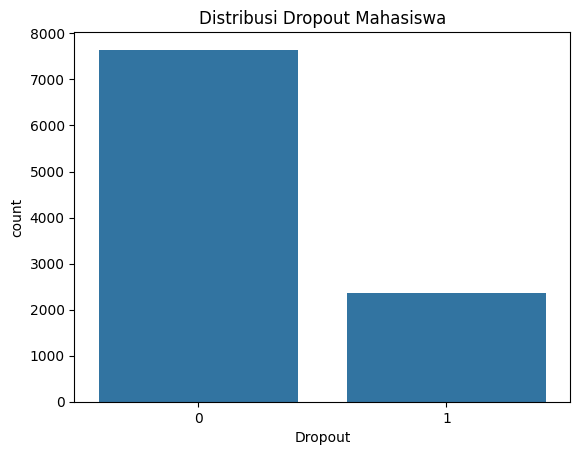

In [31]:
sns.countplot(x='Dropout', data=df)
plt.title("Distribusi Dropout Mahasiswa")
plt.show()

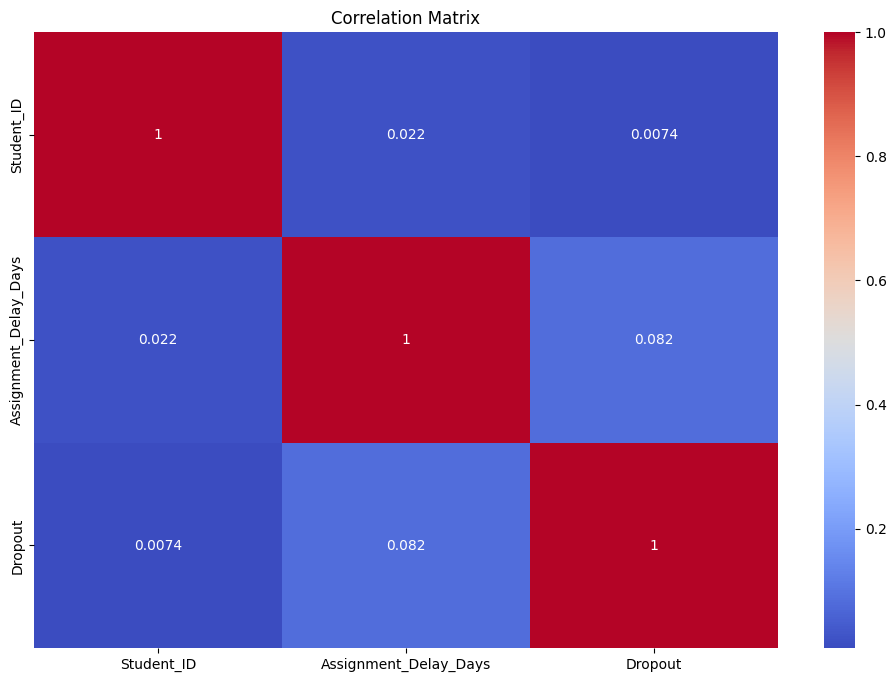

In [32]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [33]:
# Daftar kolom yang teridentifikasi sebagai numerik tetapi saat ini bertipe 'object'
# Ini perlu diubah ke numerik sebelum imputasi dengan rata-rata.
numeric_object_cols = [
    'Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
    'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA'
]

for col in numeric_object_cols:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace(',', '.', regex=False)
    df[col] = df[col].str.replace(r'\.00$', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Family_Income'].fillna(df['Family_Income'].mean(), inplace=True)
df['Stress_Index'].fillna(df['Stress_Index'].mean(), inplace=True)


if df['Parental_Education'].dtype == 'object':
    df['Parental_Education'].fillna(df['Parental_Education'].mode()[0], inplace=True)

for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)


/tmp/ipykernel_3110/1650755556.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Family_Income'].fillna(df['Family_Income'].mean(), inplace=True)
/tmp/ipykernel_3110/1650755556.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender',
    'Internet_Access',
    'Part_Time_Job',
    'Scholarship',
    'Department',
    'Parental_Education',
    'Semester' # This column was not encoded previously, causing the error
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [35]:
from scipy import stats
import numpy as np

z = np.abs(stats.zscore(df.select_dtypes(include=np.number)))

df = df[(z < 3).all(axis=1)]

In [36]:
X = df.drop("Dropout", axis=1)
y = df["Dropout"]


In [37]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Sebelum SMOTE")
print(Counter(y))

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Setelah SMOTE")
print(Counter(y_resampled))

Sebelum SMOTE
Counter({0: 7397, 1: 2261})
Setelah SMOTE
Counter({0: 7397, 1: 7397})


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier

selector = SelectFromModel(
    GradientBoostingClassifier(random_state=42),
    threshold="median"
)

selector.fit(X_train, y_train)

X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(accuracy_score(y_test, y_pred_xgb))

XGBoost
0.8611017235552552


In [42]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print(accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
0.8553565393714092
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1489
           1       0.89      0.81      0.85      1470

    accuracy                           0.86      2959
   macro avg       0.86      0.86      0.86      2959
weighted avg       0.86      0.86      0.86      2959



In [43]:
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    random_state=42,
    verbose=0
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

print("CatBoost Accuracy")
print(accuracy_score(y_test, y_pred_cat))

CatBoost Accuracy
0.8627914836093274


**CP 3**

### 2. Tuning Hyperparameter Mendalam
Kita akan menjalankan GridSearchCV untuk mencari kombinasi parameter terbaik bagi ketiga model.

In [46]:
from sklearn.model_selection import GridSearchCV

# 1. Tuning Gradient Boosting
param_gb = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6]
}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_gb, cv=3, n_jobs=-1)
grid_gb.fit(X_train, y_train)

# 2. Tuning CatBoost
param_cat = {
    'iterations': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 6, 8, 10]
}
grid_cat = GridSearchCV(CatBoostClassifier(random_state=42, verbose=0), param_cat, cv=3, n_jobs=-1)
grid_cat.fit(X_train, y_train)

# 3. Tuning XGBoost
param_xgb = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42), param_xgb, cv=3, n_jobs=-1)
grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': [100, 200, 300, 400]})

### 3. Evaluasi Hasil Optimasi

In [47]:
models = {
    'Gradient Boosting Optimized': grid_gb.best_estimator_,
    'CatBoost Optimized': grid_cat.best_estimator_,
    'XGBoost Optimized': grid_xgb.best_estimator_
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-"*30)

Gradient Boosting Optimized Accuracy: 0.8594
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1489
           1       0.89      0.81      0.85      1470

    accuracy                           0.86      2959
   macro avg       0.86      0.86      0.86      2959
weighted avg       0.86      0.86      0.86      2959

------------------------------
CatBoost Optimized Accuracy: 0.8618
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1489
           1       0.89      0.82      0.86      1470

    accuracy                           0.86      2959
   macro avg       0.86      0.86      0.86      2959
weighted avg       0.86      0.86      0.86      2959

------------------------------
XGBoost Optimized Accuracy: 0.8581
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1489
           1       0.90      0.81      0.85      1470

    

In [48]:
from sklearn.preprocessing import PolynomialFeatures

# Memilih fitur numerik penting untuk dibuat interaksinya
important_cols = ['GPA', 'Semester_GPA', 'CGPA', 'Stress_Index', 'Attendance_Rate']
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_poly = poly.fit_transform(X_resampled[important_cols])
X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(important_cols), index=X_resampled.index)

# Gabungkan kembali dengan fitur lainnya
X_final = pd.concat([X_resampled, X_poly_df.drop(columns=important_cols)], axis=1)

# Split dan Scaling ulang
X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(
    X_final, y_resampled, test_size=0.2, random_state=42
)

scaler_fin = StandardScaler()
X_train_fin = scaler_fin.fit_transform(X_train_fin)
X_test_fin = scaler_fin.transform(X_test_fin)

print(f'Jumlah fitur setelah Polynomial: {X_final.shape[1]}')

Jumlah fitur setelah Polynomial: 28


**CP 4**

In [49]:
param_grid = {
    'n_estimators': [100,200],
    'learning_rate': [0.01,0.1],
    'max_depth': [3,5]
}

grid = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]})

In [50]:
best_model = grid.best_estimator_

In [51]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': selector.get_feature_names_out(X.columns),
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

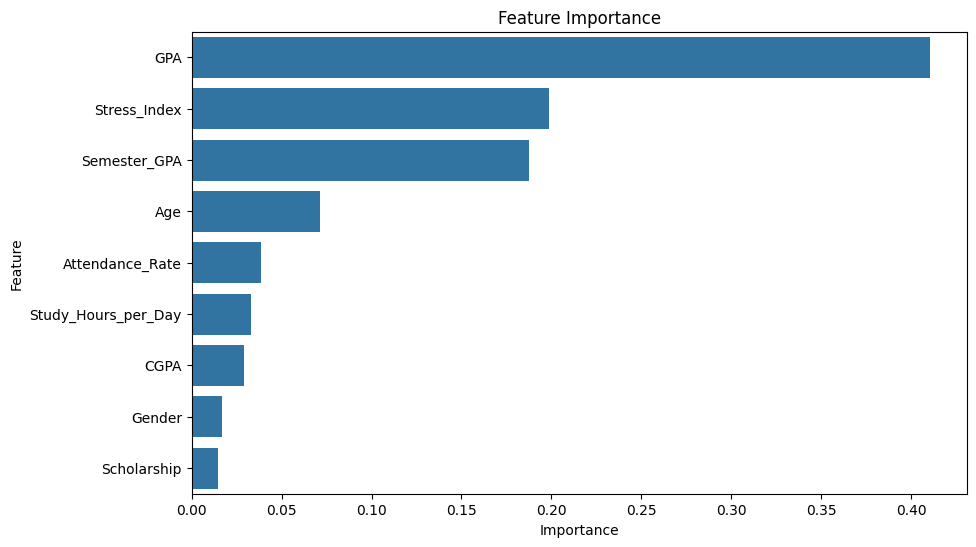

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

In [ ]:
joblib.dump(best_model, "model_dropout.pkl")